# 08_优化算法-梯度下降法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


大家好，今儿分享**梯度下降法**\~

这是一个最基本的算法，也是入门级别的，但是非常的重要！

**梯度下降法（Gradient Descent）本身是一种迭代优化算法，主要用于寻找函数的最小值**。

在机器学习和深度学习中，梯度下降法被广泛应用于优化模型参数，以最小化损失函数（或成本函数）。

其基本思想是，**通过计算损失函数的梯度（即对模型参数的偏导数），沿着梯度的反方向调整参数，使得损失函数逐步减小，直至达到最小值或接近最小值。**

咱们举一个非常直白的例子：

假设你在一个大山上迷路了，天已经黑了，你想要尽快下山找到一个安全的地方。

你的目标就是找到山脚下最低的那个点。因为是黑夜，你看不到周围的环境，只能靠摸索前进。

1. **判断方向**：你用手电筒照亮脚下的一小片区域，发现前面的地面比后面的地面低，那么你知道朝前走可以往下走。
2. **迈步前进**：你根据前后地面的高低差，决定迈多大的一步。步子不能太大，否则可能会跌倒（即步长太大可能会错过最低点）；步子也不能太小，否则会走得很慢（即步长太小收敛速度慢）。
3. **不断重复**：你每走一步，就停下来再用手电筒照一下前后左右，继续选择朝低的方向走。

最终，通过不断地判断方向和迈步前进，你会一步步接近山脚，直到找到一个你认为已经是最低点的地方。

在这个比喻中：

- **山**代表损失函数。
- **你的位置**代表模型参数。
- **山的高度**代表损失函数的值。
- **用手电筒照明判断前后高低**代表计算梯度（损失函数的导数）。
- **迈步前进**代表根据梯度更新参数。

**关键要点**：

- **梯度**：表示当前参数点的斜率，指示出损失函数增加最快的方向。
- **步长（学习率）**：决定每次更新参数的幅度。步长太大可能会错过最优点，步长太小则收敛速度慢。

通过这个过程，梯度下降法帮助模型逐步找到参数的最优值，使得损失函数最小化，从而提高模型的性能。

## 理论基础

#### 数学原理

梯度下降法的目标是找到函数 $f(\theta)$的最小值。我们可以假设 $f(\theta)$是一个损失函数，其中 $\theta$是需要优化的参数向量。

1. **梯度的定义**：梯度是一个向量，包含函数 $f(\theta)$对每个参数 $\theta_i$的偏导数。
2. 表示为：  
$\nabla f(\theta) = \left[ \frac{\partial f(\theta)}{\partial \theta_1}, \frac{\partial f(\theta)}{\partial \theta_2}, \ldots, \frac{\partial f(\theta)}{\partial \theta_n} \right]$  
梯度指向函数值增加最快的方向。
3. **梯度下降法的更新规则**：为了找到函数 $f(\theta)$的最小值，我们需要沿着梯度的反方向移动参数。
4. 更新规则：  
$\theta \leftarrow \theta - \eta \nabla f(\theta)$  
其中，$\eta$是学习率（步长），决定每次参数更新的幅度。

#### 算法流程

梯度下降法的基本流程可以分为以下几个步骤：

1. **初始化参数**：随机选择初始参数 $\theta$。
2. **计算梯度**：对于当前参数 $\theta$，计算损失函数 $f(\theta)$对每个参数的偏导数，得到梯度向量 $\nabla f(\theta)$。
3. **更新参数**：使用梯度下降法的更新规则，更新参数：  
$\theta \leftarrow \theta - \eta \nabla f(\theta)$
4. **检查收敛**：判断损失函数是否收敛。
5. 常见的收敛条件包括：

   - 损失函数值的变化量小于预设的阈值。
   - 梯度的范数小于预设的阈值。
   - 达到最大迭代次数。
6. **重复**：如果未达到收敛条件，返回步骤 2，继续迭代。
7. **输出结果**：最终的参数 $\theta$即为使损失函数最小化的参数。

### 算法流程图

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
初始化参数 θ
       ↓
   计算梯度 ▷ ∇f(θ)
       ↓
更新参数 θ = θ - η∇f(θ)
       ↓
  是否收敛？────► 是
       ↓          ↓
       否      输出结果 θ
       ↓
  重复计算梯度
```

### 详细步骤

1. **初始化参数** $\theta$：选择一个随机的初始参数向量 $\theta$。可以是随机值，也可以是零向量或其他值。
2. **计算梯度**：对于当前的参数 $\theta$，计算损失函数 $f(\theta)$对每个参数 $\theta_i$的偏导数，得到梯度向量 $\nabla f(\theta)$：


$$
\nabla f(\theta) = \left[ \frac{\partial f(\theta)}{\partial \theta_1}, \frac{\partial f(\theta)}{\partial \theta_2}, \ldots, \frac{\partial f(\theta)}{\partial \theta_n} \right]
$$


1. **更新参数**，根据梯度下降法的更新规则，调整参数：


$$
\theta \leftarrow \theta - \eta \nabla f(\theta)
$$


1. **检查收敛**：

   - 计算新的损失函数值 $f(\theta)$。
   - 检查是否满足收敛条件：
   
     - 若损失函数值的变化量 $|f(\theta_{\text{new}}) - f(\theta_{\text{old}})|$小于某个预设的阈值，则认为收敛。
     - 若梯度的范数 $||\nabla f(\theta)||$小于某个预设的阈值，则认为收敛。
     - 若达到最大迭代次数，则停止迭代。
2. **重复计算**：若未达到收敛条件，返回步骤 2，使用新的参数 $\theta$继续计算梯度并更新参数。
3. **输出结果**：最终输出参数 $\theta$，即为使损失函数 $f(\theta)$最小化的参数。

梯度下降法通过不断迭代，利用损失函数的梯度信息，沿着梯度的反方向调整参数，从而逐步逼近函数的最小值。

## 应用场景

### 梯度下降法适用的问题

梯度下降法主要适用于以下类型的问题：

1. **优化问题**：寻找函数（尤其是损失函数或目标函数）的最小值。
2. **机器学习**：优化模型参数以最小化损失函数，例如线性回归、逻辑回归、支持向量机等。
3. **深度学习**：训练神经网络，通过反向传播算法调整权重和偏置。
4. **数值计算**：解决大规模线性方程组、矩阵分解等。

#### 优点

1. **通用性强**：适用于各种类型的优化问题。
2. **计算效率高**：每次迭代只需计算一次梯度，适合大规模数据集。
3. **实现简单**：算法原理简单，易于实现。
4. **可扩展性**：可以结合多种技术（如动量、学习率衰减等）改进性能。

#### 缺点

1. **容易陷入局部最优**：对于非凸函数，可能会停留在局部最优点而非全局最优点。
2. **收敛速度慢**：对于复杂的损失函数，收敛速度可能较慢。
3. **依赖初始值**：初始参数选择对结果影响较大。
4. **学习率选择困难**：学习率太大或太小都会影响收敛效果。

### 运用时的前提条件

1. **可微性**：损失函数必须是可微的，以便计算梯度。
2. **初始参数**：需要设定初始参数，一般通过随机初始化或其他方法。
3. **学习率**：需要设定合适的学习率，常常需要通过实验调优。
4. **数据准备**：数据应当经过标准化或归一化处理，以加快收敛速度。

### 实际中的应用案例

1. **线性回归**：如预测房价。使用梯度下降法优化线性回归模型的参数，以最小化预测值与实际值之间的均方误差。
2. **逻辑回归**：如垃圾邮件分类。使用梯度下降法优化逻辑回归模型的参数，以最小化交叉熵损失，从而提高分类准确度。
3. **神经网络训练**：如图像识别。通过梯度下降法和反向传播算法，调整神经网络的权重和偏置，最终实现对图像的准确分类。
4. **推荐系统**：如电影推荐。使用矩阵分解技术，利用梯度下降法优化用户和电影的特征矩阵，以最小化预测评分与实际评分之间的误差，从而提高推荐效果。
5. **支持向量机**：分类任务，如手写数字识别。使用梯度下降法优化支持向量机的参数，以最大化分类的边界间隔。

可以看出，梯度下降法在各种机器学习和深度学习应用中都起到了关键的优化作用，帮助模型找到最优参数，从而提高预测和分类的准确性。

## 完整案例

**案例：使用梯度下降法进行线性回归预测房价**

我们将使用一个大型数据集来演示梯度下降法的应用，并进行详细的数据分析和可视化。假设我们使用的房价数据集包含多个特征（例如房间数、房龄、面积等）和目标变量（房价）。

#### 步骤概述

1. **数据加载与预处理**
2. **梯度下降法实现线性回归**
3. **模型训练与优化**
4. **复杂可视化分析**

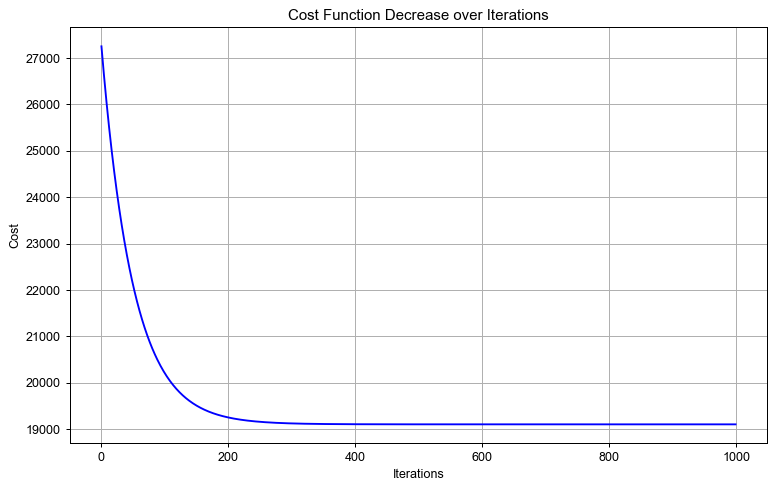

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 生成模拟数据
np.random.seed(42)
num_samples = 100000
X = np.random.rand(num_samples, 3) * 100  # 3个特征
noise = np.random.randn(num_samples) * 10
coefficients = [3.5, 2.1, -1.8]
y = X.dot(coefficients) + 5 + noise

# 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 梯度下降法实现线性回归
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradients = (1/m) * X.T.dot(errors)
        theta -= learning_rate * gradients
        cost_history[i] = compute_cost(X, y, theta)
    
    return theta, cost_history

# 初始化参数
theta = np.zeros(X_train.shape[1])
learning_rate = 0.01
iterations = 1000

# 训练模型
theta_opt, cost_history = gradient_descent(X_train, y_train, theta, learning_rate, iterations)

# 模型评估
train_predictions = X_train.dot(theta_opt)
test_predictions = X_test.dot(theta_opt)

# 可视化损失函数下降过程
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), cost_history, color='blue')
plt.title('Cost Function Decrease over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_016.png)

**可视化预测结果与真实值的对比**

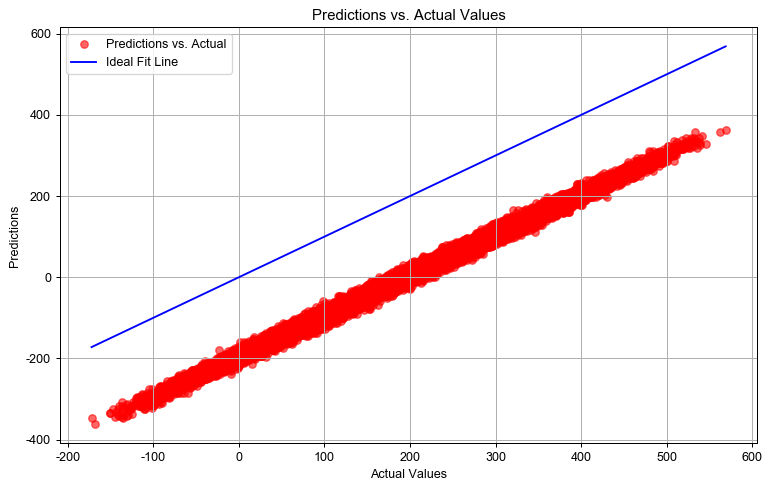

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_predictions, color='red', alpha=0.6, label='Predictions vs. Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='blue', label='Ideal Fit Line')
plt.title('Predictions vs. Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.legend()
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_017.png)

**数据分布和预测误差分析**

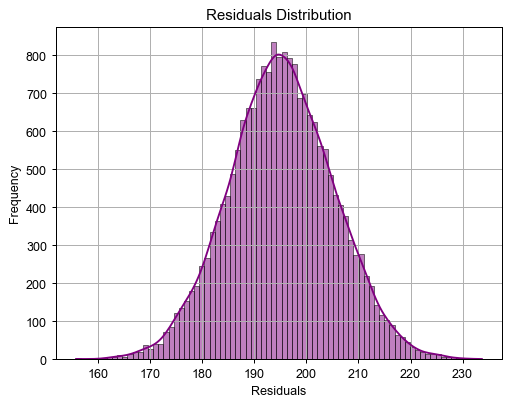

Optimized Theta Parameters: [101.45458988  60.81668675 -51.7882956 ]


In [4]:
residuals = y_test - test_predictions
sns.histplot(residuals, kde=True, color='purple')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 打印模型参数
print("Optimized Theta Parameters:", theta_opt)

![原文参考图，当前结果见代码输出](attachments/img_018.png)

具体涉及到的细节，其他部分可以参考代码中的注释：

1. **数据生成与预处理**：

   - 生成一个模拟数据集，包含3个特征和目标变量。
   - 对特征进行标准化处理。
   - 将数据集拆分为训练集和测试集。
2. **梯度下降法实现线性回归**：

   - 定义损失函数计算方法 `compute_cost`。
   - 实现梯度下降法 `gradient_descent`，更新参数并记录每次迭代的损失值。
3. **模型训练与优化**：

   - 初始化参数并设置学习率与迭代次数。
   - 训练模型并获得优化后的参数和损失历史。
4. **复杂可视化分析**：

   - 绘制损失函数随迭代次数下降的图像。
   - 绘制预测结果与实际值的对比图。
   - 绘制残差分布图，分析预测误差。

#### 结果分析

- **损失函数下降图**：显示损失函数值随迭代次数的下降情况，验证模型逐步收敛。
- **预测结果对比图**：展示模型在测试集上的预测结果与实际值的对比，评估模型性能。
- **残差分布图**：分析预测误差的分布情况，判断模型的预测效果是否存在系统性偏差。

以上整体，就是梯度下降法进行线性回归模型的训练和优化，并通过详细的可视化分析验证模型的效果。